# ผลการทดลอง stage 2 — ตัดฟีเจอร์ระดับไหนดีที่สุด

## การทดลอง

```
7 ระดับการตัดฟีเจอร์  ×  3 แบบการแบ่งข้อมูล  ×  3 โมเดล  =  63 การเทรน
```

### 7 ระดับ (ตัดสะสมกันไปเรื่อย ๆ)

| ระดับ | ตัดเพิ่มจากระดับก่อน | #feat |
|---|---|---:|
| `raw` | — (identifier ถูก encode เป็นเลข ไม่ได้ตัด) | 83 |
| `no_id` | `Flow ID` `Src IP` `Dst IP` `Timestamp` | 79 |
| `no_const` | 12 คอลัมน์ค่าคงที่ (บั๊ก CICFlowMeter ให้ 0 หมด) | 67 |
| `no_port` | `Src Port` `Dst Port` | 65 |
| `no_dup` | 8 คอลัมน์ที่ correlation = 1.0000 | 57 |
| `no_expensive` | `Active/Idle × Mean,Std,Max,Min` (คำนวณ real-time ไม่ได้) | 49 |
| `shap_top15` | SHAP คัดจากระดับ `no_port` | 15 |

### 3 แบบการแบ่งข้อมูล

| split | train | test | บอกอะไร |
|---|---|---|---|
| `random` | 80% ปนกันหมด | 20% | ทำข้อสอบชุดเดิม — **จับ leakage ไม่ได้** |
| `ovs2meta` | Normal½ + OVS | Normal½ + metasploitable | ทำข้อสอบชุดใหม่ |
| `meta2ovs` | Normal½ + metasploitable | Normal½ + OVS | ทำข้อสอบชุดใหม่ (ทิศกลับ) |

**ทำไมต้องมี 3 แบบ:** `random` อย่างเดียวจับการ "จำ" ไม่ได้ เพราะ IP เดียวกัน
อยู่ทั้ง train และ test — โมเดลที่จำ IP ได้ก็ยังทายถูก
ต้องข้าม testbed ถึงจะรู้ว่าเรียนพฤติกรรมจริงหรือแค่ท่องจำ

---

### Hyperparameter

จูนด้วย **Random Search 30 settings + 3-fold CV** บน train set เท่านั้น
ช่วงค่าอ้างอิงจาก Table I ของงานที่ benchmark บน InSDN เดียวกัน
(2022 ASYU — GBDT + SHAP on CIC-IDS2017 / CSE-CIC-IDS2018 / InSDN)

**`max_depth` จำกัดที่ 6-12 เท่ากันทุกโมเดล** สำคัญมาก เพราะ default ของ sklearn
คือไม่จำกัด ส่วน XGBoost คือ 6 ถ้าไม่คุมจะเทียบกันไม่ยุติธรรม

---

**notebook นี้อ่านผลจาก `outputs/*.csv` อย่างเดียว ไม่คำนวณอะไรใหม่**
→ ตัวเลขตรงกับที่ `.py` ผลิตเสมอ

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

import config

plt.rcParams['font.family'] = ['Thonburi', 'DejaVu Sans']

grid = pd.read_csv(config.OUT_DIR / '02_stage2_grid.csv')
print(f"{len(grid)} แถว = {grid.level.nunique()} ระดับ × "
      f"{grid.split.nunique()} split × {grid.model.nunique()} โมเดล")

63 แถว = 7 ระดับ × 3 split × 3 โมเดล


---
# แต่ละระดับตัดอะไร และตัดเพราะอะไร

ตัด **สะสมกันไปเรื่อย ๆ** ระดับหลังตัดทุกอย่างของระดับก่อน บวกกลุ่มใหม่
จะได้แยกออกว่ากลุ่มไหนมีผลแค่ไหน

## 1. `raw` (83) ไม่ตัดอะไรเลย

identifier ถูก **encode เป็นเลข** ไม่ได้ตัดทิ้ง เพื่อให้ทดลองได้ว่า
"ถ้าไม่ตัดจะเป็นยังไง" ไม่งั้นตอบคำถามนี้ไม่ได้เลย

## 2. `no_id` (79) ตัด identifier 4 ตัว

| คอลัมน์ | ค่าไม่ซ้ำ | เหตุผล |
|---|---:|---|
| `Flow ID` | 234,971 (68%) | string จาก IP+Port+Protocol เกือบเป็นเลขประจำแถว |
| `Src IP` | 122,868 (36%) | สูงเพราะ DDoS ปลอม source IP · เครื่องที่ยิงใช้ IP ตายตัว |
| `Dst IP` | 1,081 | เครื่องเหยื่อใช้ IP เดิมตลอด |
| `Timestamp` | 1,392 | attack ยิงเป็นช่วงเวลา โมเดลจำ "ช่วงนี้คือ attack" |

**ไม่ได้ตัดเพราะไร้ประโยชน์ แต่ตัดเพราะมีประโยชน์เกินไปแบบผิด ๆ**
โมเดลจะจำ IP แทนที่จะเรียนพฤติกรรม ใช้กับเครือข่ายจริงไม่ได้

**หลักฐาน:** SHAP ที่ระดับ `raw` จัด `Timestamp` เป็นอันดับ 1 และ `Flow ID` อันดับ 2
(identifier กิน 3 ใน 5 อันดับแรก) และ macro-F1 ข้าม testbed อยู่ที่ **0.07**

## 3. `no_const` (67) ตัดคอลัมน์ค่าคงที่ 12 ตัว

บั๊กของ CICFlowMeter คอลัมน์กลุ่ม bulk ออกมาเป็น 0 ทั้งคอลัมน์

**ทำไมต้องตัดก่อนใช้ SHAP:** ฟีเจอร์ค่าเดียวจะได้ SHAP = 0
แล้วเราจะสรุปว่า "ไม่สำคัญ" ซึ่ง**ผิด** มันไม่สำคัญเพราะ*ไม่มีข้อมูล*
ไม่ใช่เพราะโมเดลพิจารณาแล้วไม่ใช้

**และถ้าไม่ตัดจะเคลมเกินจริง** ว่า SHAP ลดฟีเจอร์ได้ 83→15
ทั้งที่ 12 ตัวนั้นตัดได้ด้วยโค้ดบรรทัดเดียว ไม่ต้องใช้ SHAP

## 4. `no_port` (65) ตัด `Src Port` `Dst Port`

ใน testbed port ผูกกับชนิด attack เกือบ 1:1 (BFA→22 · Web-Attack→80)
โมเดลจะจำ port แทนพฤติกรรม พอเจอ brute-force ที่ port 2222 ก็พลาด

**พิสูจน์แล้ว:** พอตัด identifier ออก `Dst Port` ไต่จากอันดับ 7 ขึ้นมาเป็น **อันดับ 3**
แล้วพอตัดคอลัมน์ค่าคงที่อีกชั้น ขึ้นเป็น **อันดับ 1**
→ โมเดลไม่ได้หันไปเรียนพฤติกรรม แต่**หา shortcut ตัวถัดไป**

## 5. `no_dup` (57) ตัดคอลัมน์ซ้ำ 8 ตัว

คู่ที่ correlation = **1.0000** (ข้อมูลเดียวกันคนละชื่อ) เก็บชื่อมาตรฐานกว่าไว้

| เก็บ | ตัด |
|---|---|
| `Tot Fwd Pkts` | `Subflow Fwd Pkts` |
| `Tot Bwd Pkts` | `Subflow Bwd Pkts` |
| `TotLen Fwd Pkts` | `Subflow Fwd Byts` |
| `TotLen Bwd Pkts` | `Subflow Bwd Byts` |
| `Fwd Pkt Len Mean` | `Fwd Seg Size Avg` |
| `Bwd Pkt Len Mean` | `Bwd Seg Size Avg` |
| `PSH Flag Cnt` | `Bwd PSH Flags` |
| `URG Flag Cnt` | `Bwd URG Flags` |

**กระทบ SHAP โดยตรง:** ฟีเจอร์ซ้ำกัน 2 ตัวจะแบ่งความสำคัญกันคนละครึ่ง
ทำให้**ทั้งคู่ดูไม่สำคัญ** ทั้งที่จริงสำคัญมาก อาจตกรอบ Top-K ทั้งคู่

## 6. `no_expensive` (49) ตัด `Active/Idle × Mean,Std,Max,Min`

ฟีเจอร์กลุ่มนี้ **ต้องรอ flow จบก่อนถึงคำนวณได้** ใช้กรอง real-time ไม่ได้

เป็นข้ออ้างหลักของการลดฟีเจอร์ที่เราเขียนไว้ตั้งแต่ต้น แต่**ไม่เคยพิสูจน์**
ระดับนี้จึงมีไว้ทดสอบว่าตัดแล้วเสียอะไรจริงไหม

## 7. `shap_top15` (15) SHAP คัด

เอา SHAP จากระดับ `no_port` มาเฉลี่ยข้ามคลาส แล้วตัด Top-15
**นี่คือระดับเดียวที่ใช้ XAI ตัดสินใจ** ระดับ 1-6 ตัดด้วยเหตุผลเชิงโครงสร้าง


In [ ]:
# รายชื่อจริงที่ 01 คำนวณไว้ (ไม่ใช่ hardcode)
import json

drops = json.loads((config.OUT_DIR / '01_drop_lists.json').read_text(encoding='utf-8'))
for group, cols in drops.items():
    print(f"\n{group}  ({len(cols)} คอลัมน์)")
    for c in cols:
        print(f"    {c}")


---
# ตารางหลัก — 7 ระดับ × 9 คอลัมน์

ค่าในตารางคือ **macro-F1** (เฉลี่ยแบบให้ทุกคลาสน้ำหนักเท่ากัน)

ใช้ macro ไม่ใช่ accuracy เพราะข้อมูล imbalance 7,173 เท่า
(DDoS 121,942 แถว · U2R 17 แถว) — accuracy จะถูกคลาสใหญ่กลบ

In [6]:
MODELS = ['DecisionTree', 'RandomForest', 'XGBoost']
SHORT = {'DecisionTree': 'DT', 'RandomForest': 'RF', 'XGBoost': 'XGB'}

main = grid.pivot_table(index='level', columns=['split', 'model'], values='f1')
main = main.reindex(config.FEATURE_LEVELS)
main = main[[(s, m) for s in config.SPLITS for m in MODELS]]
main.columns = pd.MultiIndex.from_tuples(
    [(s, SHORT[m]) for s, m in main.columns])

n_feat = grid.groupby('level')['n_features'].first().reindex(config.FEATURE_LEVELS)
main.insert(0, ('', '#feat'), n_feat.astype(int))

# ไฮไลต์ตัวที่ชนะในแต่ละ (ระดับ × split)
# เขียวเข้ม = ชนะ · เขียวอ่อน = ต่างจากผู้ชนะไม่เกิน 0.005 (ถือว่าเสมอ)
def highlight_winner(df):
    st = pd.DataFrame('', index=df.index, columns=df.columns)
    for s in config.SPLITS:
        cols = [c for c in df.columns if c[0] == s]
        for i in df.index:
            row = df.loc[i, cols]
            best = row.max()
            for col in cols:
                if row[col] == best:
                    st.loc[i, col] = 'background-color:#2d9c5a;color:white;font-weight:bold'
                elif best - row[col] <= 0.005:
                    st.loc[i, col] = 'background-color:#c7ecd4'
    return st


display(main.round(4).style.apply(highlight_winner, axis=None))

## วิธีอ่านตาราง

**อ่านตามแนวนอน** — ระดับเดียวกัน เทียบว่าโมเดลไหนดีกว่า

**อ่านตามแนวตั้ง** — โมเดลเดียวกัน เทียบว่าตัดฟีเจอร์แล้วดีขึ้น/แย่ลง

**เทียบข้ามกลุ่ม split** ← สำคัญที่สุด
ดูว่าค่าใน `random` กับ `meta2ovs` ห่างกันแค่ไหน
→ ห่างมาก = โมเดลจำ testbed มากกว่าเรียนพฤติกรรม

## โมเดลไหนชนะกี่ครั้ง


In [7]:
# นับว่าโมเดลไหนชนะกี่ครั้ง แยกตาม split
wins = []
for s in config.SPLITS:
    sub = grid[grid.split == s]
    for lv in config.FEATURE_LEVELS:
        d = sub[sub.level == lv]
        if d.empty:
            continue
        wins.append({'split': s, 'level': lv,
                     'winner': SHORT[d.loc[d.f1.idxmax(), 'model']]})

w = pd.DataFrame(wins)
tally = w.pivot_table(index='winner', columns='split', aggfunc='size', fill_value=0)
tally['รวม'] = tally.sum(axis=1)
display(tally.sort_values('รวม', ascending=False))

print('จำนวนครั้งที่ชนะ (จาก 7 ระดับ ต่อ split)')
print('ระวัง: ชนะบน random อย่างเดียวไม่พอ — raw ชนะเพราะจำ ไม่ใช่เก่ง')


split,meta2ovs,ovs2meta,random,รวม
winner,,,,
XGB,3,2,6,11
DT,3,2,0,5
RF,1,3,1,5


จำนวนครั้งที่ชนะ (จาก 7 ระดับ ต่อ split)
ระวัง: ชนะบน random อย่างเดียวไม่พอ — raw ชนะเพราะจำ ไม่ใช่เก่ง


---
# ช่องว่าง random − cross-env = ขนาดของการ "จำ"

ถ้าโมเดลเรียนพฤติกรรมจริง ผลบนข้อสอบใหม่ควรใกล้ข้อสอบเดิม
ถ้าโมเดลจำ testbed ผลจะร่วงแรงเมื่อเปลี่ยน testbed

In [8]:
g = grid.pivot_table(index=['level', 'model'], columns='split', values='f1')
g['cross_env_avg'] = g[['ovs2meta', 'meta2ovs']].mean(axis=1)
g['gap'] = g['random'] - g['cross_env_avg']

gap = g['gap'].unstack()[MODELS].reindex(config.FEATURE_LEVELS)
gap.columns = [SHORT[m] for m in gap.columns]
gap.insert(0, '#feat', n_feat.astype(int))

display(gap.round(4).style.background_gradient(
    subset=['DT', 'RF', 'XGB'], cmap='Reds'))

,#feat,DT,RF,XGB
level,,,,
raw,83,0.796500,0.624400,0.377300
no_id,79,0.508000,0.531900,0.504800
no_const,67,0.512200,0.549400,0.504800
no_port,65,0.468800,0.461200,0.490000
no_dup,57,0.443200,0.454300,0.490000
no_expensive,49,0.430400,0.463600,0.490200
shap_top15,15,0.509300,0.521600,0.520900


**สีเข้ม = ช่องว่างกว้าง = จำมากกว่าเรียน**

⚠️ **ข้อควรระวัง:** ช่องว่างแคบไม่ได้แปลว่าดีเสมอไป
ถ้าโมเดลแย่ทั้งสองฝั่ง ช่องว่างก็แคบ — ต้องดูคู่กับตารางหลักด้านบน

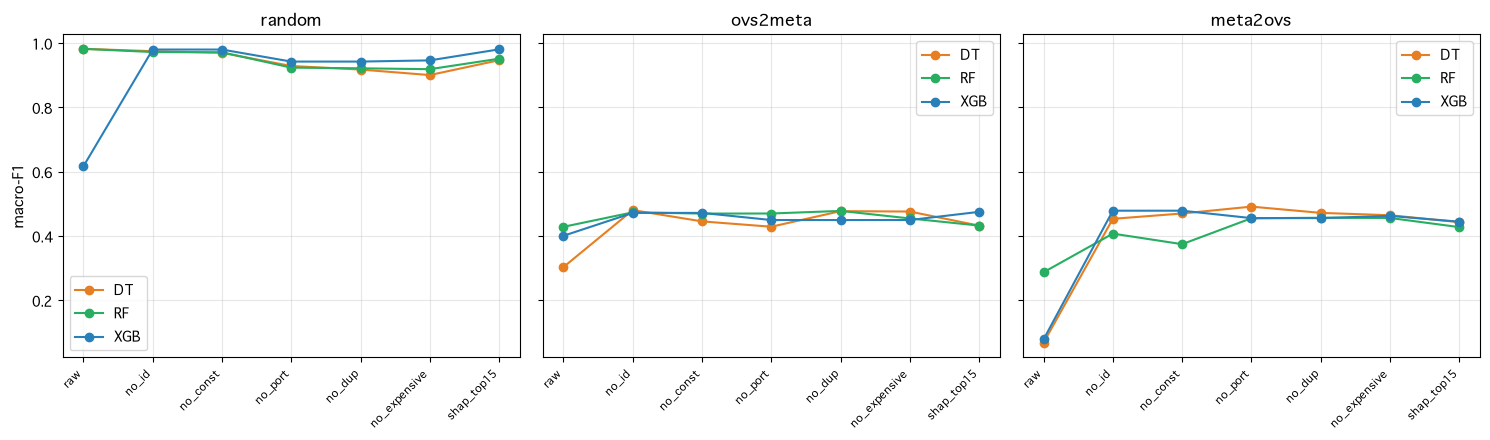

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
colors = {'DecisionTree': '#e67e22', 'RandomForest': '#27ae60', 'XGBoost': '#2980b9'}

for ax, split in zip(axes, config.SPLITS):
    sub = grid[grid.split == split]
    for m in MODELS:
        d = sub[sub.model == m].set_index('level').reindex(config.FEATURE_LEVELS)
        ax.plot(range(len(d)), d['f1'], marker='o', label=SHORT[m], color=colors[m])
    ax.set_xticks(range(len(config.FEATURE_LEVELS)))
    ax.set_xticklabels(config.FEATURE_LEVELS, rotation=45, ha='right', fontsize=8)
    ax.set_title(split)
    ax.grid(alpha=.3)
    ax.legend()

axes[0].set_ylabel('macro-F1')
plt.tight_layout()
plt.savefig(config.FIG_DIR / 'stage2_levels.png', dpi=150, bbox_inches='tight')
plt.show()

---
# สิ่งที่ตารางบอก

## 1. `raw` + DecisionTree = ลายเซ็นของการจำ

```
random 0.9819  →  meta2ovs 0.0679      ช่องว่าง 0.914
```

ทำข้อสอบชุดเดิมได้เกือบเต็ม แต่พอเปลี่ยน testbed **พังสิ้นเชิง**

นี่คือหลักฐานที่ตอบคำถาม *"รู้ได้ไงว่าถ้าไม่ตัด identifier มันจะผิด"* ได้ตรงที่สุด

## 2. ตัด constant + dup = ได้ฟรี

```
no_id (79)   =  no_const (67)     ทุกช่องเท่ากันเป๊ะ
no_port (65) =  no_dup (57)       ทุกช่องเท่ากันเป๊ะ
```

**ลด 20 ฟีเจอร์โดยผลไม่เปลี่ยนแม้แต่ทศนิยมที่ 4** — ยืนยันว่าคอลัมน์พวกนั้นไม่มีข้อมูลจริง

## 3. `shap_top15` — ผลที่ดีที่สุดของงาน

```
15 ฟีเจอร์  XGB random 0.9803
79 ฟีเจอร์  XGB random 0.9797
```

**ใช้ฟีเจอร์ 19% ได้ผลเท่ากัน** — พิสูจน์ว่า SHAP feature selection ได้ผลจริง

## 4. ตัด Port มีต้นทุนที่ stage 2

```
no_const (67, มี Port)  XGB random 0.9797
no_port  (65, ไม่มี)    XGB random 0.9423     ↓ 0.037
```

ต่างจากผลของ stage 1 ที่ Port ทำร้าย — **สองงานต้องการ Port คนละแบบ**
(stage 2 แยกชนิด attack: Port มีข้อมูลจริง · stage 1 แยก attack จาก normal: Port เป็น shortcut)

## 5. XGBoost ชนะ `random` 5 จาก 7 ระดับ

2 ระดับที่แพ้คือ `raw` — แพ้เพราะ XGBoost จัดการฟีเจอร์ที่มีค่าไม่ซ้ำเยอะได้ไม่ดี
(`Flow ID` ไม่ซ้ำ 68% ของแถว) ส่วน DT/RF ชนะเพราะ**จำ** ซึ่งพังตอนข้าม testbed

---

## ⚠️ ยังตอบไม่ได้จากตารางนี้

cross-env ทุกช่องอยู่ราว **0.42–0.49** ต่างกันแค่ 0.03–0.07
ซึ่งอาจอยู่ในระดับ noise — **ยังสรุปไม่ได้ว่าโมเดลไหนดีกว่าตอนข้าม testbed**

และตัวเลข 0.45 **ไม่ได้แปลว่า "ได้ประมาณครึ่ง"** ต้องดู per-class ถึงจะรู้ว่ามาจากอะไร

---
# per-class — ตัวเลข 0.45 มาจากอะไร

macro-F1 เฉลี่ยทุกคลาสเท่ากัน ดังนั้น 0.45 **ไม่ได้แปลว่าทุกคลาสได้ 0.45**
อาจเป็น 3 คลาสดี + 2 คลาสพัง ก็ได้ — ต้องแยกดูถึงจะตีความได้

*(เก็บเฉพาะ XGBoost — ถ้าทำครบ 3 โมเดลจะได้ 9 ตารางซึ่งอ่านไม่ไหว)*


In [ ]:
for split in config.SPLITS:
    t = pd.read_csv(config.OUT_DIR / f'02_per_class_{split}.csv', index_col=0)
    print(f'\n=== split: {split} ===')
    display(t.round(4).style.background_gradient(
        subset=[c for c in t.columns if c != 'support'],
        cmap='RdYlGn', vmin=0, vmax=1))


## สิ่งที่ per-class เปิดเผย

**บน `random` ทุกคลาสเขียวหมด** — โมเดลทำได้ดีทุกชนิด attack

**บน cross-env แยกเป็น 2 กลุ่มชัดเจน:**

| คลาส | cross-env F1 | |
|---|---:|---|
| DDoS | 0.9998 | 🟢 ข้าม testbed ได้สมบูรณ์ |
| Probe | 0.7116 | 🟡 พอใช้ |
| Normal | 0.6785 | 🟡 พอใช้ |
| **DoS** | **0.0017** | 🔴 พังสนิท |
| **BFA** | **0.0000** | 🔴 ทายไม่ถูกเลยสักแถว |

**ตัวเลข 0.45 = 3 คลาสใช้ได้ + 2 คลาสพัง** ไม่ใช่ "ได้ประมาณครึ่ง"

---

## ทำไม 2 คลาสถึงพัง — คนละสาเหตุกัน

เทียบการกระจายของฟีเจอร์ระหว่าง OVS กับ metasploitable ในคลาสเดียวกัน:

| คลาส | ฟีเจอร์ที่ต่างกันเกิน 1 SD | median diff | cross-env F1 |
|---|---:|---:|---:|
| DDoS | 2 / 47 | 0.09 | 0.9998 |
| BFA | 2 / 58 | 0.14 | **0.0000** |
| Probe | 6 / 65 | 0.73 | 0.7116 |
| **DoS** | **12 / 63** | **0.47** | **0.0017** |

**DDoS** — ข้อมูลแทบเหมือนกันสองที่ (ต่างแค่ 2 ฟีเจอร์) → ข้ามได้สมบูรณ์ สมเหตุสมผล

**DoS** — ต่างกันจริง 12 ฟีเจอร์ (OVS 52,471 แถว vs metasploitable 1,145 แถว)
น่าจะเป็นคนละเครื่องมือคนละเทคนิค แค่ติดป้ายชื่อเดียวกัน
→ **distribution shift แก้ด้วยการปรับโมเดลไม่ได้**

**BFA** — ⚠️ ต่างกันน้อยที่สุด (2/58) แต่กลับได้ 0 → **ขัดกับสมมติฐาน**
สาเหตุน่าจะเป็น **class imbalance**: ตอน meta2ovs เทรนด้วย BFA แค่ 295 แถว
เทียบกับ DDoS 73,529 แถว โมเดลแทบไม่เคยทาย BFA เลย
→ **อันนี้แก้ได้** ด้วย `class_weight` หรือ resampling

---

## ข้อจำกัดที่ต้องระบุในรายงาน

ตัวเลข cross-env ~0.45 **สะท้อนความไม่สอดคล้องของ label ข้าม testbed**
มากกว่าสะท้อนคุณภาพของโมเดล — เพราะ "DoS" ในสองไฟล์อาจเป็นคนละอย่างกัน

จึงไม่ควรใช้ตัวเลขนี้เปรียบเทียบโมเดล แต่ใช้ดู **แนวโน้ม** ว่าตัดฟีเจอร์แล้วดีขึ้นไหม


---
# SHAP — โมเดลใช้อะไรตัดสินใจ

XGBoost บอกไม่ได้เองว่าฟีเจอร์ไหนสำคัญ (`feature_importances_` เป็น Gini importance
ซึ่ง bias เข้าหาฟีเจอร์ที่มีค่าหลากหลาย และไม่บอกทิศทาง) จึงต้องใช้ **TreeSHAP**

SHAP คำนวณจาก **train set เท่านั้น** ถ้าคำนวณบน test แล้วเอาไปเลือกฟีเจอร์ = leakage
และคำนวณจากโมเดลที่ **จูนพารามิเตอร์แล้ว**


In [ ]:
imp = pd.read_csv(config.OUT_DIR / '03_shap_no_port.csv', index_col=0)

n = len(imp.columns)
fig, axes = plt.subplots((n + 1) // 2, 2, figsize=(13, 3 * ((n + 1) // 2)))
for ax, cls in zip(axes.ravel(), imp.columns):
    top = imp[cls].nlargest(8).sort_values()
    ax.barh(range(len(top)), top.values, color='#c0392b')
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top.index, fontsize=8)
    ax.set_title(f'{cls}  (อันดับ 1 กิน {top.values[-1]:.0%})', fontsize=10)
for ax in axes.ravel()[n:]:
    ax.axis('off')
plt.tight_layout()
plt.savefig(config.FIG_DIR / 'shap_per_class.png', dpi=150, bbox_inches='tight')
plt.show()


**ชื่อฟีเจอร์ในแต่ละกล่องไม่เหมือนกัน = แต่ละ attack ใช้หลักฐานคนละอย่าง**

| Attack | ฟีเจอร์อันดับ 1 | กินความสำคัญ |
|---|---|---:|
| DDoS | `Protocol` | 45% |
| BOTNET | `Flow IAT Min` | 25% |
| Probe | `Bwd Header Len` | 23% |
| Normal | `Init Bwd Win Byts` | 20% |
| BFA | `Bwd Header Len` | 19% |
| Web-Attack | `Init Bwd Win Byts` | 15% |
| DoS | `Fwd Header Len` | 12% |
| U2R | `Bwd Pkt Len Mean` | 8% |

### ✅ ตรงกับงานที่ตีพิมพ์

`Init Bwd Win Byts` ติด **Top-5 ของทั้ง 8 คลาส** — ตัวเดียวที่ติดครบ

งานที่ benchmark บน InSDN เดียวกัน (2022 ASYU) รายงานว่า `Init Bwd Win Byts`
เป็นฟีเจอร์สำคัญที่สุดของ InSDN เช่นกัน → **pipeline ของเราให้ผลสอดคล้องกับงานที่ตีพิมพ์**


## SHAP ยืนยันว่าตัด identifier ถูก

ตัวเลข = อันดับความสำคัญ (1 = สำคัญที่สุด) · `-` = ถูกตัดไปแล้วในระดับนั้น


In [ ]:
rk = pd.read_csv(config.OUT_DIR / '03_leak_column_rank.csv', index_col=0)
display(rk.fillna('-'))
print('พอตัด identifier ออก Port ไต่อันดับขึ้นมาแทนที่')
print('→ โมเดลไม่ได้หันไปเรียนพฤติกรรม แต่หา shortcut ตัวถัดไป')


---
# แล้วจะรวมฟีเจอร์ยังไง

แต่ละคลาสได้ฟีเจอร์ไม่เหมือนกัน แต่เราต้องการ **ชุดเดียว** ไปเทรน

| วิธี | นิยาม | ได้กี่ตัว |
|---|---|---:|
| `union` | ติด Top-15 ของคลาสไหนก็เอา | **39** |
| `intersection` | ต้องติด Top-15 ของ **ทุกคลาส** | **1** |
| `mean` | เฉลี่ยข้ามคลาสก่อน แล้วตัด Top-15 | **15** |
| `dynamic` | แต่ละคลาสเก็บจนสะสมถึง 90% แล้ว union | **45** |

**`intersection` เหลือตัวเดียวคือ `Flow IAT Min`** — เข้มเกินไปจนใช้ไม่ได้

**`union` 39 ตัวจาก 65** — ยังเยอะ แทบไม่ต่างจากไม่กรอง

`dynamic` เลือกจำนวนต่างกันตามคลาสจริง:
DDoS ใช้ 11 · BOTNET 10 · BFA 21 · Normal 23 · U2R 26 · Probe 27 · **DoS 28**

→ **คลาสที่ตรวจจับยากต้องใช้ฟีเจอร์มากกว่า** สอดคล้องกับผล cross-env ที่ DoS พังที่สุด

---

## ขั้นถัดไป (ยังไม่ใช่เนื้อหาของ present นี้)

ทดลองเบื้องต้น: เลือก **15 ฟีเจอร์** ด้วยวิธี `mean` → macro-F1 **0.9775**
เทียบกับใช้ 67 ฟีเจอร์ = 0.9922 → **ต่างกัน 0.015 โดยใช้ฟีเจอร์ 22%**

ยังต้องทดลองต่อว่า K เท่าไหร่คุ้มที่สุด และวิธีรวมแบบไหนดีกว่ากัน
